In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 08 — Persistent homology, persistence modules, and reading diagrams

Read `lessons/08_lesson.md` first. Predict each result before execution. This is a fully worked lab; independent exercises and solutions are separate. All real examples before Stage 12 restrict digit displays to training data.

## Setup
This cell locates the project, loads standard numerical tools, and creates only this stage’s output folder. The mathematical work begins below.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "data/manifest.json").exists() and (p / "src/shape_lab").exists()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook inside the extracted listening_to_shape_lab folder.")
sys.path.insert(0, str(ROOT / "src"))
from shape_lab.display import show_and_save, save_json
OUT = ROOT / "reports/stage_08"
OUT.mkdir(parents=True, exist_ok=True)
print("Output folder:", OUT.relative_to(ROOT))

Output folder: reports/stage_08


## Exact square: derive first, then calculate
The expected positive H₁ interval is [1,√2). Ordinary H₀ retains one essential interval.

H0:
[[ 0.  1.]
 [ 0.  1.]
 [ 0.  1.]
 [ 0. inf]]
H1:
[[1.         1.41421356]]


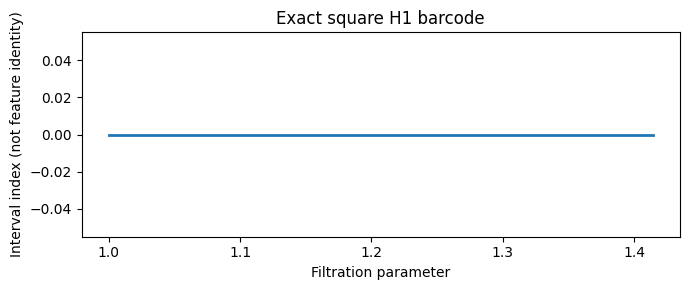

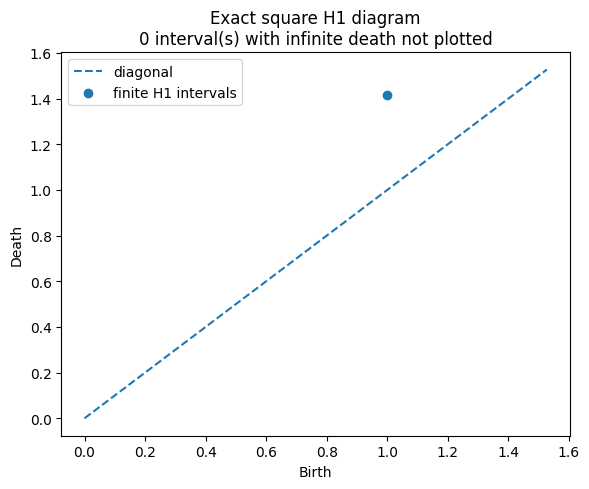

Truncated at 1.1, H1: [[ 1. inf]]


In [3]:
from shape_lab.persistence import rips_filtration, persistent_homology, diagram, pixel_filtration
from shape_lab.display import plot_diagram, plot_barcode
square = np.array([[0.,0.],[1.,0.],[1.,1.],[0.,1.]])
bars = persistent_homology(rips_filtration(square))
print("H0:", diagram(bars,0), "H1:", diagram(bars,1), sep="\n")
assert np.allclose(diagram(bars,1), [[1., np.sqrt(2)]])
plot_barcode(bars,1,"Exact square H1 barcode")
show_and_save(OUT / "square_barcode.png")
plot_diagram(bars,1,"Exact square H1 diagram")
show_and_save(OUT / "square_diagram.png")
truncated = persistent_homology(rips_filtration(square, max_edge=1.1))
print("Truncated at 1.1, H1:", diagram(truncated,1))
assert np.isinf(diagram(truncated,1)[0,1])

## Real handwriting barcode
The parameter is intensity-derived, not Euclidean edge length. Infinite endpoints are stored as JSON null in reports, with conventions stated.

Training sample ID: 0
Real H1 intervals: [[0.5 1. ]]


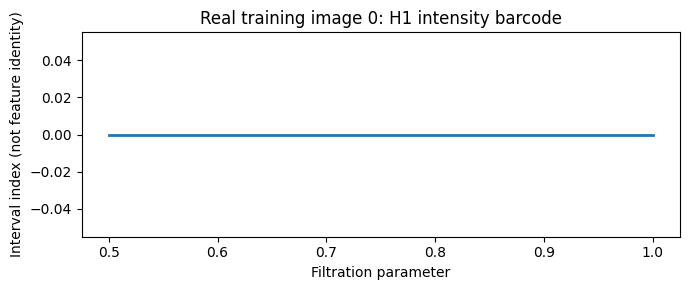

In [4]:
from shape_lab.data import digit_example
image, sample_id = digit_example(0)
real_bars = persistent_homology(pixel_filtration(1-image.astype(float)/16))
print("Training sample ID:", sample_id)
print("Real H1 intervals:", diagram(real_bars,1))
plot_barcode(real_bars,1,f"Real training image {sample_id}: H1 intensity barcode")
show_and_save(OUT / "digit_barcode.png")
save_json(OUT / "results.json", {"square_H1": diagram(bars,1),
          "square_truncated_H1": diagram(truncated,1), "infinite_endpoint_encoding": "null",
          "real_sample_id": sample_id, "real_H1": diagram(real_bars,1),
          "pixel_axis": "f=1-intensity/16"})

## Interpretation check
Does the infinite bar in the truncated square imply a loop forever? No: the full computation already shows its death at √2. Explain this before moving on.

## Mastery gate
Read and derive barcodes and diagrams, interpret endpoint/truncation conventions, and explain the need for induced maps.

A successful Run All is computational evidence, not a learner pass. Complete the lesson’s original exercises before reading `solutions/08_solutions.md`. Record independent work, corrections and a delayed re-test in your learner ledger.

## Sources and conventions
Source IDs: R1, R2, R8, L1, L3; direct links and assignments are in `docs/SOURCES.md`. Core conventions are in `docs/MATHEMATICAL_CONVENTIONS.md`.